# Unknown Peak Identification

스펙트럼에서 미지 피크를 발견했을 때, **이 이온이 어떤 물질인지** 알아내는 과정입니다.

1. m/z에서 **가능한 분자식 후보** 열거
2. 화학 규칙으로 **불가능한 후보 제거**
3. **동위원소 패턴** 비교로 순위 매기기
4. **Fragmentation pattern** 대조로 최종 확인

## 환경 설정

In [ ]:
!pip install -q pyopenms scipy matplotlib numpy pandas

import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pyopenms as oms
import os

from echo_tof.molecule import Molecule
from echo_tof.formula_enum import find_compositions
from echo_tof.isotope_calc import IsotopicDistributionCalculator
from echo_tof.filters import FormulaFilter
from echo_tof.pattern import MoleculePattern

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('echo_tof package loaded.')


## 실측 데이터 로드

TOF-MS 데이터에서 TIC 피크 시점의 mass spectrum을 추출합니다.

In [ ]:
exp = oms.MSExperiment()
oms.MzMLFile().load('echo-tof-colab/data/mzml/20260330_TOFMS.mzML', exp)

# TIC peak spectrum
best_spec = max((s for s in exp if s.getMSLevel() == 1),
                key=lambda s: sum(s.get_peaks()[1]))
mz_data, int_data = best_spec.get_peaks()
print(f'Spectrum at RT={best_spec.getRT():.1f}s, {len(mz_data)} ions')


## Step 1. Unknown Peak 선택

- 스펙트럼에서 강한 피크 중 **정체를 모르는 피크**를 선택
- 여기서는 예시로 특정 m/z를 지정하여 동정 과정을 시연
- 실제로는 Top-N 피크를 자동 탐색하는 것도 가능

In [ ]:
# 강한 피크 Top 10
top10_idx = np.argsort(int_data)[-10:][::-1]
print(f'{"Rank":>4s} {"m/z":>10s} {"Intensity":>12s} {"Rel%":>6s}')
print('-' * 35)
for rank, idx in enumerate(top10_idx, 1):
    rel = int_data[idx] / int_data.max() * 100
    print(f'{rank:4d} {mz_data[idx]:10.4f} {int_data[idx]:12.1f} {rel:5.1f}%')

# 동정 대상 선택
target_mz = mz_data[top10_idx[0]]
print(f'\nTarget: m/z = {target_mz:.4f}')


## Step 2. Formula Finder Pipeline

`FormulaFinderPipeline`을 사용하여 분자식 후보를 자동으로 탐색합니다.

파이프라인이 수행하는 작업:
1. **분자식 열거**: MW ± tolerance 범위의 모든 원소 조합
2. **화학 규칙 필터링**: DBE, N-rule, H/C ratio 등 5단계 필터
3. **동위원소 패턴 매칭**: 이론 vs 실측 패턴 비교 → Cluster Error, RMS Error
4. **4가지 오차 기반 순위**: 각 지표별 순위 → Combined Score로 종합

### 순위 지표
| 지표 | 의미 |
|------|------|
| Intensity Cluster Error | M, M+1, M+2 상대 강도 차이 |
| RMS Mass Error | 각 동위원소 피크의 질량 오차 |
| Mass Cluster Error | |RMS| + 100 × Cluster Error |
| **Combined Score** | **위 3개 순위의 가중 합 → 최종 순위** |
> **코드 풀이**:  패키지의 내부 동작 원리는
> [Formula Finder](../Formula%20Finder/) 폴더의 노트북에서 단계별로 설명합니다.

In [ ]:
from echo_tof.pipeline import FormulaFinderPipeline

# Adduct 보정 → neutral MW
PROTON = 1.00728
neutral_mw = target_mz + PROTON  # [M-H]- assumed
tol_da = neutral_mw * 5e-6       # 5 ppm

print(f'Target m/z: {target_mz:.4f}')
print(f'Adduct: [M-H]- → neutral MW = {neutral_mw:.4f}')
print(f'Tolerance: ±{tol_da:.4f} Da (5 ppm)')
print()

# 실측 동위원소 클러스터 추출
obs_mz_list, obs_int_list = [], []
for i in range(4):  # M, M+1, M+2, M+3
    search = target_mz + i * 1.00335
    mask = np.abs(mz_data - search) < 0.05
    if mask.any():
        best = np.argmax(int_data[mask])
        obs_mz_list.append(float(mz_data[mask][best]))
        obs_int_list.append(float(int_data[mask][best]))
    else:
        obs_mz_list.append(search)
        obs_int_list.append(0.0)

use_peaks = [True] * len(obs_mz_list)
weighting = [1.0] * len(obs_mz_list)

# FormulaFinder Pipeline 실행
pipeline = FormulaFinderPipeline()
pipeline.init_ms(
    mass_tol_ppm=5.0,
    int_tol=100.0,
    min_comp='',
    max_comp='C50 H200 N10 O10 S5',
    dbe_from=-0.5,
    dbe_to=40.0,
)
pipeline.set_pattern(obs_mz_list, obs_int_list, use_peaks, weighting, charge=1)

n_candidates = pipeline.propose_elemental_compositions()
results = pipeline.results

print(f'Candidates found: {n_candidates}')
print()

# 결과 출력 (Combined Score 순위)
print(f'{"Rank":>4s} {"Formula":>20s} {"err(ppm)":>9s} {"ClustErr":>9s} {"RMS":>9s} {"MassClust":>10s} {"Combined":>9s} {"RDB":>5s}')
print('-' * 80)
for i, r in enumerate(results[:10], 1):
    print(f'{i:4d} {r.composition:>20s} {r.error_ppm:+8.1f} '
          f'{r.intensity_cluster_error:9.1f} {r.rms_error:9.2f} '
          f'{r.mass_cluster_error:10.1f} {r.combined_order:9.1f} {r.rdb:5.1f}')


### 결과 해석

파이프라인이 자동으로 수행한 작업:
- 분자식 열거 → 화학 규칙 필터링 → 동위원소 패턴 매칭 → 순위 산출
- **Combined Score**가 낮을수록 좋은 후보
- 1위 후보가 정답일 확률이 가장 높음

In [ ]:
# Top 1 후보 확인
if results:
    best = results[0]
    print(f'Best candidate: {best.composition}')
    print(f'  MW:              {best.monoisotopic_mass:.4f}')
    print(f'  Mass error:      {best.error_ppm:+.1f} ppm')
    print(f'  Cluster Error:   {best.intensity_cluster_error:.1f}')
    print(f'  RMS Error:       {best.rms_error:.2f}')
    print(f'  RDB:             {best.rdb:.1f}')
    print(f'  Even electron:   {best.is_even_electron}')
else:
    print('No candidates found.')


## Step 4. 동위원소 패턴으로 순위 매기기

필터링 후에도 후보가 여러 개 남을 수 있습니다.
이때 **실측 동위원소 패턴**과 **이론 패턴**을 비교하면 결정적 판별이 가능합니다.

### 핵심 지표
- **Cluster Error**: M, M+1, M+2의 상대 강도 차이 (RMS)
  - 값이 작을수록 패턴이 잘 맞음
- **RMS Mass Error**: 각 동위원소 피크의 질량 오차 RMS

`echo_tof.isotope_calc`는 **컨볼루션 기반**으로 정밀한 이론 패턴을 생성합니다.

In [ ]:
# 동위원소 패턴 비교
calc = IsotopicDistributionCalculator()

# 실측 동위원소 클러스터 추출
def extract_obs_cluster(mz_arr, int_arr, mono_mz, n_peaks=4, tol_da=0.05):
    obs_mz, obs_int = [], []
    for i in range(n_peaks):
        target = mono_mz + i * 1.00335
        mask = np.abs(mz_arr - target) < tol_da
        if mask.any():
            best = np.argmax(int_arr[mask])
            obs_mz.append(mz_arr[mask][best])
            obs_int.append(int_arr[mask][best])
        else:
            obs_mz.append(target)
            obs_int.append(0.0)
    return np.array(obs_mz), np.array(obs_int)

obs_mz, obs_int = extract_obs_cluster(mz_data, int_data, target_mz)
obs_rel = obs_int / obs_int.max() * 100 if obs_int.max() > 0 else obs_int

# 각 후보의 이론 패턴과 비교
scored = []
for f in filtered:
    peaks = calc.calculate(f['mol'].composition)
    theo_int = np.array([p.abundance for p in peaks[:4]])
    theo_rel = theo_int / theo_int.max() * 100 if theo_int.max() > 0 else theo_int
    
    # Cluster Error = RMS of relative intensity difference
    n = min(len(obs_rel), len(theo_rel))
    cluster_err = np.sqrt(np.mean((obs_rel[:n] - theo_rel[:n])**2))
    
    f['cluster_error'] = cluster_err
    f['theo_rel'] = theo_rel
    scored.append(f)

scored.sort(key=lambda x: x['cluster_error'])
print(f'{"Rank":>4s} {"Formula":>20s} {"err(ppm)":>10s} {"ClusterErr":>12s} {"RDB":>5s}')
print('-' * 55)
for i, s in enumerate(scored, 1):
    m = s['mol']
    print(f'{i:4d} {m.composition:>20s} {s["error_ppm"]:+9.1f} {s["cluster_error"]:12.1f} {m.rdb:5.1f}')


### 동위원소 패턴 비교 시각화
상위 후보의 이론 패턴과 실측 패턴을 오버레이합니다.

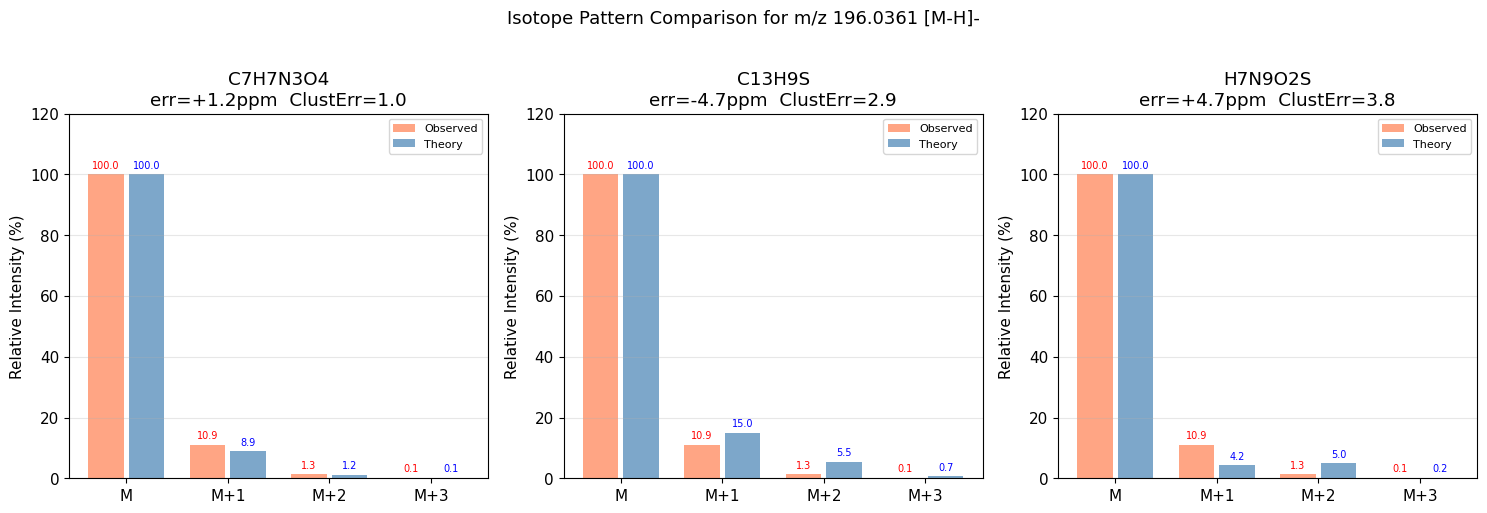

In [1]:
# Isotope pattern visualization: top candidates vs observed
n_show = min(3, len(scored))
fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 5))
if n_show == 1: axes = [axes]
for ax, s in zip(axes, scored[:n_show]):
    n_pk = min(len(obs_rel), len(s['theo_rel']))
    x = np.arange(n_pk)
    ax.bar(x - 0.2, obs_rel[:n_pk], 0.35, color='coral', alpha=0.7, label='Observed')
    ax.bar(x + 0.2, s['theo_rel'][:n_pk], 0.35, color='steelblue', alpha=0.7, label='Theory')
    ax.set_xticks(x)
    ax.set_xticklabels(['M+%d'%i if i>0 else 'M' for i in range(n_pk)])
    ax.set_ylabel('Rel. Int (%)')
    ax.set_title('%s\nerr=%+.1fppm ClustErr=%.1f' % (s['mol'].composition, s['error_ppm'], s['cluster_error']))
    ax.legend(fontsize=8); ax.set_ylim(0, 120); ax.grid(alpha=0.3, axis='y')
plt.suptitle('Isotope Pattern Comparison (m/z %.4f)' % target_mz, y=1.02)
plt.tight_layout()
plt.show()

## Step 5. Fragmentation Pattern 검증

동위원소 패턴만으로 후보를 좁히지 못할 때, **MS/MS fragmentation 패턴**이 결정적입니다.

### 원리
- 분자가 충돌 에너지를 받으면 특정 결합이 끊어져 **fragment ion**이 생성
- 어떤 결합이 끊어지는지는 **분자 구조**에 따라 결정됨
- 따라서 분자식이 같아도 **구조가 다르면 fragmentation 패턴이 다름**

### Fragmentation 예측 방법
- **결합 절단 (Bond Cleavage)**: 단일결합을 하나씩 끊어서 가능한 fragment 생성
  - C-C, C-N, C-O 등 heteroatom 인접 결합 우선
  - ring bond는 별도 처리 (ring opening)
- **중성 소실 (Neutral Loss)**: 모분자에서 작은 중성 분자가 떨어져 나가는 패턴
  - H₂O (-18.011), CO (-27.995), NO (-29.997), NO₂ (-45.993)
  - HCN (-27.011), CO₂ (-43.990)
- **Rearrangement**: McLafferty 재배열 등 수소 이동을 동반한 절단

### 검증 방법
1. 후보 분자식으로 예상 fragment m/z 리스트 생성
2. 실측 MS/MS 스펙트럼에서 해당 m/z가 **존재하는지** 탐색
3. 매칭된 fragment 수가 많을수록 → 해당 분자식의 신뢰도 ↑
4. `echo_tof.fragment`의 slope 최적화로 **ppm 오차의 체계적 편향**도 보정

In [ ]:
# Neutral Loss 기반 fragment 예측
NEUTRAL_LOSSES = {
    'H2O':  18.0106, 'CO':   27.9949, 'HCN':  27.0109,
    'NO':   29.9974, 'CO2':  43.9898, 'NO2':  45.9929,
    'CH2O': 30.0106, 'C2H2': 26.0157,
}

def predict_fragments_neutral_loss(parent_mz, losses=NEUTRAL_LOSSES):
    """Neutral loss 기반 fragment m/z 예측"""
    frags = []
    for name, mass in losses.items():
        frag_mz = parent_mz - mass
        if frag_mz > 50:  # m/z 50 이상만
            frags.append({'loss': name, 'loss_mass': mass, 'frag_mz': frag_mz})
    return frags

# Top 후보의 예측 fragments
best_candidate = scored[0] if scored else None
if best_candidate:
    pred_frags = predict_fragments_neutral_loss(target_mz)
    print(f'Predicted fragments for {best_candidate["mol"].composition} (m/z {target_mz:.4f}):')
    print(f'{"Loss":>8s} {"Mass":>8s} {"Frag m/z":>10s}')
    for f in pred_frags:
        print(f'{f["loss"]:>8s} {f["loss_mass"]:8.4f} {f["frag_mz"]:10.4f}')


### Fragment 실측 확인

- MRM-HR 데이터에서 target m/z의 MS/MS 스펙트럼을 추출
- 예측된 fragment m/z가 **실제로 존재하는지** ±10 ppm으로 탐색
- 매칭 결과로 분자식 후보의 최종 신뢰도를 판정

In [ ]:
# MRM-HR 데이터에서 MS/MS 확인
exp_mrm = oms.MSExperiment()
oms.MzMLFile().load('echo-tof-colab/data/mzml/20260330_MRMHR_Q1Q3_Final.mzML', exp_mrm)

# target_mz에 해당하는 MS/MS 스펙트럼 수집
msms_mz, msms_int = [], []
for spec in exp_mrm:
    if spec.getMSLevel() == 2:
        precs = spec.getPrecursors()
        if precs:
            prec_mz = precs[0].getMZ()
            if abs(prec_mz - target_mz) / target_mz * 1e6 < 50:
                mz_arr, int_arr = spec.get_peaks()
                msms_mz.extend(mz_arr)
                msms_int.extend(int_arr)

if msms_mz:
    msms_mz = np.array(msms_mz)
    msms_int = np.array(msms_int)
    print(f'MS/MS data: {len(msms_mz)} peaks from precursor ~{target_mz:.3f}')
    
    # Fragment matching
    matched = []
    for frag in pred_frags:
        fmz = frag['frag_mz']
        tol = fmz * 10e-6  # 10 ppm
        mask = np.abs(msms_mz - fmz) < tol
        if mask.any():
            best_idx = np.argmax(msms_int[mask])
            obs_fmz = msms_mz[mask][best_idx]
            obs_fint = msms_int[mask][best_idx]
            ppm = (obs_fmz - fmz) / fmz * 1e6
            frag['matched'] = True
            frag['obs_mz'] = obs_fmz
            frag['obs_int'] = obs_fint
            frag['ppm'] = ppm
            matched.append(frag)
        else:
            frag['matched'] = False
    
    print(f'\nMatched: {len(matched)}/{len(pred_frags)} fragments')
    for m in matched:
        print(f'  -{m["loss"]:6s} pred={m["frag_mz"]:.4f} obs={m["obs_mz"]:.4f} '
              f'err={m["ppm"]:+.1f}ppm int={m["obs_int"]:.0f}')
else:
    print(f'No MS/MS data found for precursor m/z {target_mz:.3f}')


### Fragment 매칭 시각화
예측된 neutral loss fragment가 실측에서 매칭된 결과를 표시합니다.

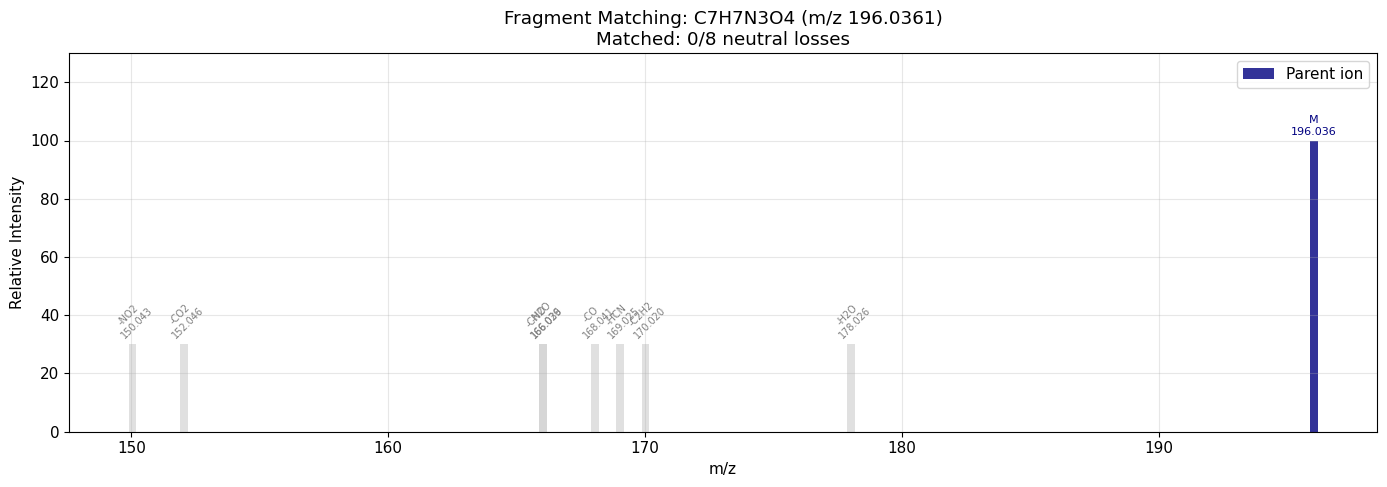

In [2]:
# Fragment matching visualization
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([target_mz], [100], width=0.3, color='navy', alpha=0.8, label='Parent')
for f in pred_frags:
    h = 60 if f.get('matched') else 30
    c = 'green' if f.get('matched') else 'lightgray'
    ax.bar([f['frag_mz']], [h], width=0.3, color=c, alpha=0.7)
    lbl = '-%s\n%.3f' % (f['loss'], f['frag_mz'])
    ax.text(f['frag_mz'], h+2, lbl, ha='center', fontsize=7, rotation=45,
           color='darkgreen' if f.get('matched') else 'gray')
n_m = len([f for f in pred_frags if f.get('matched')])
ax.set_title('Fragment Matching: %s -- %d/%d matched' % (best_candidate['mol'].composition, n_m, len(pred_frags)))
ax.set_xlabel('m/z'); ax.set_ylabel('Rel. Int'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6. 종합 판정

m/z 기반 분자식 열거, 동위원소 패턴, fragmentation pattern을 종합하여 최종 동정합니다.

| 단계 | 방법 | 판별 기준 |
|------|------|----------|
| 분자식 열거 | MW ± 5 ppm 내 원소 조합 | 후보 생성 |
| 화학 필터 | DBE, N-rule, H/C ratio | 불가능한 후보 제거 |
| 동위원소 패턴 | Cluster Error | 패턴 일치도로 순위 |
| **Fragmentation** | **Neutral loss matching** | **구조 확인 — 결정적** |

In [ ]:
# 최종 요약
if best_candidate:
    m = best_candidate['mol']
    n_matched = len([f for f in pred_frags if f.get('matched')])
    n_total = len(pred_frags)
    
    print('=== Identification Result ===')
    print(f'Target m/z:     {target_mz:.4f}')
    print(f'Best formula:   {m.composition}')
    print(f'MW:             {m.monoisotopic_mass:.4f}')
    print(f'Mass error:     {best_candidate["error_ppm"]:+.1f} ppm')
    print(f'RDB:            {m.rdb:.1f}')
    print(f'Cluster Error:  {best_candidate["cluster_error"]:.1f}')
    print(f'Fragments:      {n_matched}/{n_total} matched')
    
    # Confidence
    if best_candidate['cluster_error'] < 10 and n_matched >= 2:
        print(f'Confidence:     HIGH')
    elif best_candidate['cluster_error'] < 20 or n_matched >= 1:
        print(f'Confidence:     MEDIUM')
    else:
        print(f'Confidence:     LOW')


## Summary

| Step | Input | Output |
|------|-------|--------|
| 분자식 열거 | m/z + adduct | 원소 조합 후보 리스트 |
| 화학 필터 | 후보 리스트 | 화학적으로 가능한 후보만 |
| 동위원소 패턴 | 실측 M/M+1/M+2 | Cluster Error로 순위 |
| Fragmentation | 실측 MS/MS | neutral loss 매칭 → 구조 확인 |

### m/z만으로는 부족한 이유
- C₇H₅N₃O₆ (TNT)과 C₅H₁₁N₂O₄S₂는 MW가 0.002 Da 차이 → 5 ppm이면 둘 다 후보
- 동위원소 패턴: S 포함 여부로 M+2 강도가 다름 → 구분 가능
- Fragmentation: -NO₂ loss는 니트로기가 있어야만 → TNT 확정

---

⬅️ **Prev:** [m/z Prediction](09%20mz%20Prediction.ipynb) | **Next:** [Fragmentation Assignment](11%20Fragmentation%20Assignment.ipynb) ➡️